# EDA Шахматного Датасета для Выбора Примеров

**Цель:** Проанализировать датасет шахматных партий с отмеченными хайлайтами, чтобы понять характеристики данных и выбрать репрезентативные примеры для few-shot промптов LLM.

**Данные:**
- `id`: Уникальный идентификатор партии.
- `white_elo`, `black_elo`: Рейтинг Эло игроков.
- `moves`: Последовательность ходов в формате UCI (например, 'e2e4 c7c6 ...').
- `marks`: Начальный и конечный полуход хайлайта (например, '47,53').

## 1. Импорты и Загрузка Данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import chess
import chess.pgn # Хотя ходы в UCI, PGN парсер может быть полезен для длины
import io
from tqdm.notebook import tqdm # Для индикатора прогресса

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
DATA_FILE = 'full_labeled.csv'

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Датасет успешно загружен. Форма: {df.shape}")
except FileNotFoundError:
    print(f"Ошибка: Файл '{DATA_FILE}' не найден.")
except Exception as e:
    print(f"Ошибка при загрузке файла: {e}")

Датасет успешно загружен. Форма: (229699, 5)


## 2. Первичный Осмотр и Очистка Данных

In [5]:
if 'df' in locals():
    print("Первые 5 строк:")
    display(df.head())
    print("\nИнформация о типах данных и пропущенных значениях:")
    df.info()
    print("\nПроверка на явные дубликаты по id:")
    print(f"Количество дублирующихся id: {df.duplicated(subset=['id']).sum()}")
    print("\nПроверка на пропущенные значения:")
    print(df.isnull().sum())

Первые 5 строк:


,id,white_elo,black_elo,moves,marks
0,787zsVup,1638.0,1851.0,e2e4 c7c6 f2f4 d7d5 e4d5 c6d5 g1f3 b8c6 d2d3 g...,"47,53"
1,F8M8OS71,1760.0,1823.0,e2e4 c7c5 g1f3 d7d6 c2c3 g8f6 d2d3 a7a6 b1d2 e...,"52,56"
2,MQSyb3KW,1877.0,1909.0,e2e4 c7c5 c2c3 d7d6 d2d4 c5d4 c3d4 b7b6 b1c3 c...,"126,130"
3,4MWQCxQ6,1741.0,1625.0,e2e4 e7e5 d2d3 b8c6 g1f3 f8c5 f1e2 g8f6 e1g1 e...,"31,35"
4,e9AY2m5j,1766.0,1733.0,e2e4 c7c5 f1c4 e7e6 g1f3 d7d5 e4d5 e6d5 c4b5 b...,"49,55"



Информация о типах данных и пропущенных значениях:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229699 entries, 0 to 229698
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         229699 non-null  object 
 1   white_elo  229697 non-null  float64
 2   black_elo  229697 non-null  float64
 3   moves      229699 non-null  object 
 4   marks      229699 non-null  object 
dtypes: float64(2), object(3)
memory usage: 8.8+ MB

Проверка на явные дубликаты по id:
Количество дублирующихся id: 0

Проверка на пропущенные значения:
id           0
white_elo    2
black_elo    2
moves        0
marks        0
dtype: int64


In [6]:
df.dropna(subset=['white_elo', 'black_elo'], inplace=True)
print(f"Размер DataFrame после удаления строк с пропущенными Elo: {df.shape}")

Размер DataFrame после удаления строк с пропущенными Elo: (229697, 5)


## 3. Инженерия Признаков

Извлечем полезную информацию из строк `moves` и `marks`.

In [8]:
def get_game_length(moves_uci_str):
    """Парсит строку ходов UCI и возвращает количество полуходов."""
    if pd.isna(moves_uci_str) or not moves_uci_str:
        return 0
    moves = moves_uci_str.split()
    return len(moves)

def parse_marks(marks_str):
    """Парсит строку 'start,end' и возвращает кортеж (start, end, length)."""
    if pd.isna(marks_str) or not marks_str:
        return pd.NA, pd.NA, pd.NA
    try:
        start, end = map(int, marks_str.split(','))
        length = end - start + 1
        if start < 0 or end < 0 or length <= 0:
             return pd.NA, pd.NA, pd.NA
        return start, end, length
    except (ValueError, TypeError):
        return pd.NA, pd.NA, pd.NA

In [11]:
if 'df' in locals():
    df['game_len_halfmoves'] = df['moves'].apply(get_game_length)

    # Парсим 'marks'
    marks_parsed = df['marks'].apply(parse_marks)
    df['highlight_start'] = marks_parsed.apply(lambda x: x[0] if pd.notna(x) else pd.NA)
    df['highlight_end'] = marks_parsed.apply(lambda x: x[1] if pd.notna(x) else pd.NA)
    df['highlight_len'] = marks_parsed.apply(lambda x: x[2] if pd.notna(x) else pd.NA)

    # Преобразуем в числовые типы, обрабатывая возможные NA
    df['highlight_start'] = pd.to_numeric(df['highlight_start'], errors='coerce')
    df['highlight_end'] = pd.to_numeric(df['highlight_end'], errors='coerce')
    df['highlight_len'] = pd.to_numeric(df['highlight_len'], errors='coerce')

    # Вычисляем относительное начало хайлайта
    df['highlight_start_percent'] = (df['highlight_start'] / df['game_len_halfmoves']).fillna(0)
    # Ограничиваем значение от 0 до 1 на всякий случай
    df['highlight_start_percent'] = df['highlight_start_percent'].clip(0, 1)

    # Добавляем разницу в рейтинге
    df['elo_diff'] = (df['white_elo'] - df['black_elo']).abs()

    print("\nDataFrame с новыми признаками:")
    display(df[['id', 'white_elo', 'black_elo', 'elo_diff', 'game_len_halfmoves', 'highlight_start', 'highlight_end', 'highlight_len', 'highlight_start_percent']].head())

    print("\nСтатистика по новым числовым признакам:")
    display(df[['white_elo', 'black_elo', 'elo_diff', 'game_len_halfmoves', 'highlight_start', 'highlight_len', 'highlight_start_percent']].describe())

Exception ignored in: <function tqdm.__del__ at 0x000001558224D260>
Traceback (most recent call last):
  File "C:\projects\study\heuristic_extractor\.conda\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\projects\study\heuristic_extractor\.conda\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'



DataFrame с новыми признаками:


,id,white_elo,black_elo,elo_diff,game_len_halfmoves,highlight_start,highlight_end,highlight_len,highlight_start_percent
0,787zsVup,1638.0,1851.0,213.0,77,47,53,7,0.610390
1,F8M8OS71,1760.0,1823.0,63.0,66,52,56,5,0.787879
2,MQSyb3KW,1877.0,1909.0,32.0,148,126,130,5,0.851351
3,4MWQCxQ6,1741.0,1625.0,116.0,111,31,35,5,0.279279
4,e9AY2m5j,1766.0,1733.0,33.0,70,49,55,7,0.700000



Статистика по новым числовым признакам:


,white_elo,black_elo,elo_diff,game_len_halfmoves,highlight_start,highlight_len,highlight_start_percent
count,229697.000000,229697.000000,229697.000000,229697.000000,229697.000000,229697.000000,229697.000000
mean,1952.524169,1954.654362,76.346853,93.806972,56.958763,5.630256,0.654625
std,269.229017,270.250990,97.537636,37.038637,24.651940,1.804947,0.235834
min,772.000000,765.000000,0.000000,5.000000,2.000000,3.000000,0.016667
25%,1755.000000,1756.000000,17.000000,64.000000,39.000000,5.000000,0.469388
50%,1896.000000,1897.000000,43.000000,92.000000,54.000000,5.000000,0.659574
75%,2105.000000,2107.000000,95.000000,122.000000,71.000000,7.000000,0.898305
max,3219.000000,3259.000000,1152.000000,291.000000,275.000000,27.000000,0.992780


## 4. Анализ Распределений

### 4.1 Анализ Рейтингов (Elo)

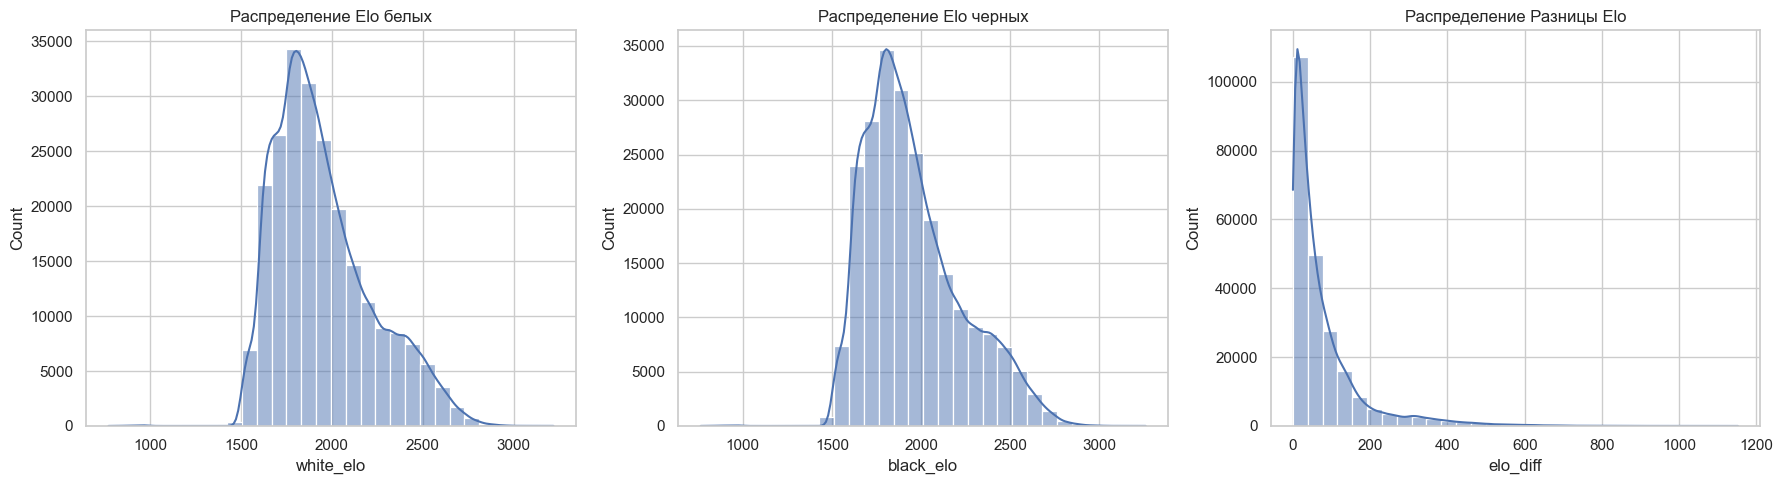

In [22]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df['white_elo'], bins=30, kde=True, ax=axes[0])
    axes[0].set_title('Распределение Elo белых')

    sns.histplot(df['black_elo'], bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Распределение Elo черных')

    sns.histplot(df['elo_diff'], bins=30, kde=True, ax=axes[2])
    axes[2].set_title('Распределение Разницы Elo')

    plt.tight_layout()
    plt.show()

1.  **Распределение Elo Белых и Черных:**
    *   Оба распределения (для белых и для черных) очень похожи друг на друга.
    *   Они являются **унимодальными** (имеют один ярко выраженный пик).
    *   Пик концентрации игроков находится в диапазоне примерно **1700-1900 Elo**.
    *   Распределения **скошены вправо** (positive skew), что означает наличие "хвоста" из игроков с более высоким рейтингом, но их количество значительно меньше по сравнению с игроками в пиковом диапазоне.
    *   Основная масса игроков имеет рейтинг примерно от 1500 до 2300 Elo. Игроков с рейтингом ниже ~1400 и выше ~2500 заметно меньше.

2.  **Распределение Разницы Elo (`elo_diff`):**
    *   Это распределение **сильно скошено вправо** с очень **выраженным пиком около нуля**.
    *   **Подавляющее большинство партий** играется между соперниками с **небольшой разницей в рейтинге** (вероятно, менее 100-150 пунктов).
    *   Частота партий резко падает с увеличением разницы в силе игроков. Игры с большим разрывом в Elo (> 300-400 пунктов) встречаются значительно реже.

**Общий Вывод по Elo:** Датасет в основном состоит из партий игроков среднего и продвинутого любительского уровня (примерно 1500-2300 Elo), которые чаще всего играют с соперниками близкой силы. В датасете меньше представлены как новички, так и профессионалы/топ-игроки.

### 4.2 Анализ Длины Партии

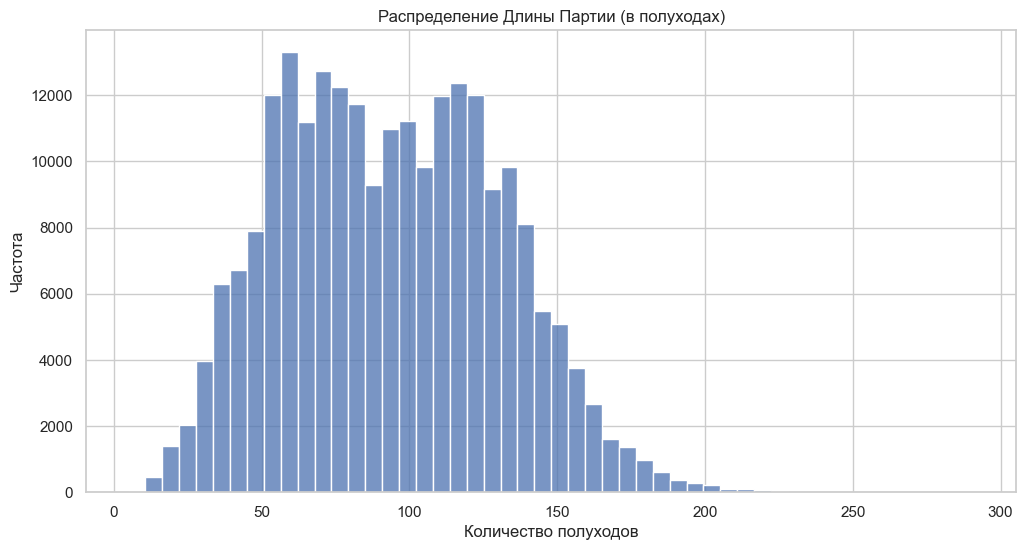

Основные квантили длины партии:
0.01     24.0
0.10     47.0
0.25     64.0
0.50     92.0
0.75    122.0
0.90    142.0
0.99    179.0
Name: game_len_halfmoves, dtype: float64


In [23]:
if 'df' in locals():
    sns.histplot(df['game_len_halfmoves'], bins=50, kde=False)
    plt.title('Распределение Длины Партии (в полуходах)')
    plt.xlabel('Количество полуходов')
    plt.ylabel('Частота')
    plt.show()

    print(f"Основные квантили длины партии:\n{df['game_len_halfmoves'].quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])}")

1.  **Форма Распределения:**
    *   Распределение не является строго унимодальным (однопиковым); наблюдается несколько локальных пиков, особенно в диапазоне от 50 до 130 полуходов.
    *   Распределение **скошено вправо**, что указывает на наличие длинного "хвоста" из относительно небольшого числа очень долгих партий.
    *   Основная масса партий сконцентрирована в диапазоне примерно от 50 до 150 полуходов.

2.  **Типичная Длина Партии:**
    *   **Медианная длина (50% квантиль)** составляет **92 полухода** (или 46 полных ходов). Это означает, что половина партий в датасете короче этого значения, а половина – длиннее.
    *   Межквартильный размах (IQR), охватывающий центральные 50% данных, составляет от 64 (Q1) до 122 (Q3) полуходов (т.е., от 32 до 61 полных ходов).

3.  **Короткие и Длинные Партии:**
    *   **Короткие партии:** Только 10% партий имеют длину менее 47 полуходов (~24 ходов), и лишь 1% – менее 24 полуходов (12 ходов). Очень короткие партии редки.
    *   **Длинные партии:** 90% партий завершаются до 142 полуходов (~71 ход). Очень длинные партии (более ~90 ходов или 180 полуходов) составляют лишь около 1% от всего датасета.

**Общий Вывод по Длине Партии:** Типичная партия в этом датасете длится около 46 полных ходов (92 полухода). Присутствует значительное разнообразие по длине, но большинство игр укладывается в диапазон от 32 до 61 хода. Очень короткие и очень длинные партии встречаются сравнительно редко.

### 4.3 Анализ Характеристик Хайлайтов

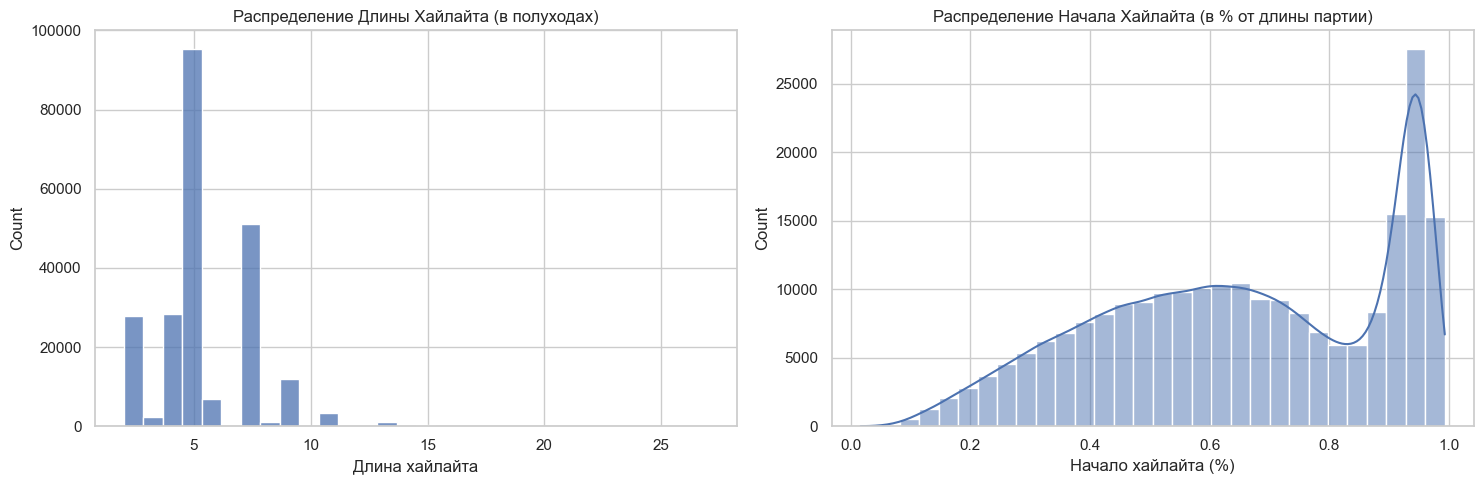

Основные квантили длины хайлайта:
0.10    2.0
0.25    4.0
0.50    5.0
0.75    7.0
0.90    7.0
Name: highlight_len, dtype: float64

Основные квантили начала хайлайта (%):
0.10    0.323308
0.25    0.469388
0.50    0.659574
0.75    0.898305
0.90    0.949367
Name: highlight_start_percent, dtype: float64


In [25]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df['highlight_len'].dropna(), bins=30, kde=False, ax=axes[0])
    axes[0].set_title('Распределение Длины Хайлайта (в полуходах)')
    axes[0].set_xlabel('Длина хайлайта')

    sns.histplot(df['highlight_start_percent'].dropna(), bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Распределение Начала Хайлайта (в % от длины партии)')
    axes[1].set_xlabel('Начало хайлайта (%)')

    plt.tight_layout()
    plt.show()

    print(f"Основные квантили длины хайлайта:\n{df['highlight_len'].dropna().quantile([0.1, 0.25, 0.5, 0.75, 0.9])}")
    print(f"\nОсновные квантили начала хайлайта (%):\n{df['highlight_start_percent'].dropna().quantile([0.1, 0.25, 0.5, 0.75, 0.9])}")

1.  **Распределение Длины Хайлайта (`highlight_len`):**
    *   Распределение **дискретное** и имеет несколько **очень выраженных пиков**.
    *   **Наиболее частая длина хайлайта – 5 полуходов**, за ней следует **7 полуходов**. Также заметны пики на 3 и 9 полуходах.
    *   **Медианная длина (50% квантиль)** составляет **5 полуходов**.
    *   **Большинство хайлайтов очень короткие:** 75% хайлайтов имеют длину 7 полуходов или менее. Интересно, что 90% квантиль также равен 7.0, что подчеркивает концентрацию данных на коротких сегментах. Хайлайты длиннее ~10 полуходов крайне редки.

2.  **Распределение Начала Хайлайта (`highlight_start_percent`):**
    *   Распределение имеет **бимодальную (двухпиковую) форму**.
    *   Первый, более **широкий пик** охватывает **середину и вторую половину партии** (примерно от 40% до 80% длины игры).
    *   Второй, **очень высокий и узкий пик** находится **в самом конце партии** (примерно 95%-100% длины игры).
    *   **Медианное начало (50% квантиль)** находится около **66%** длины партии.
    *   **Большинство хайлайтов происходит поздно:** 75% хайлайтов начинаются после ~47% игры, а 90% – после ~90% игры. Резкий пик в конце говорит о том, что очень многие хайлайты в этом датасете относятся к самым последним, решающим моментам партии.

**Общий Вывод по Хайлайтам:** Хайлайты в данном датасете преимущественно **очень короткие** (чаще всего 5 или 7 полуходов) и чаще всего возникают во **второй половине игры**, с особенно высокой концентрацией **прямо перед завершением партии**. Это может указывать на то, что в качестве "хайлайтов" часто отмечались решающие зевки, тактические удары или матовые комбинации в эндшпиле.

## 5. Анализ Взаимосвязей

Посмотрим, есть ли связь между рейтингом, длиной партии и характеристиками хайлайтов.

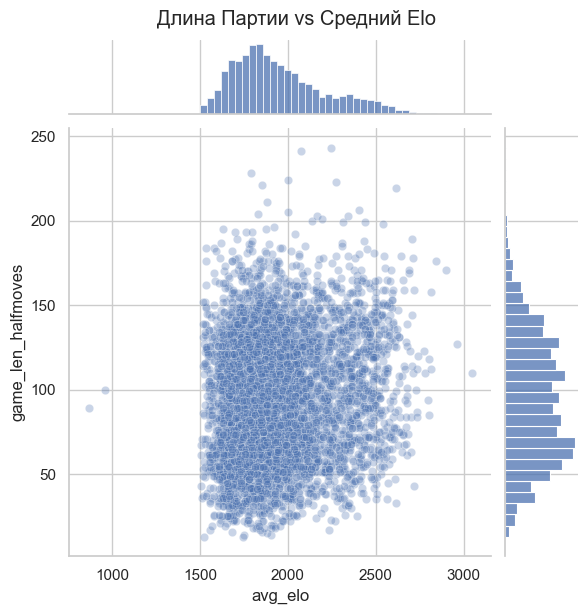

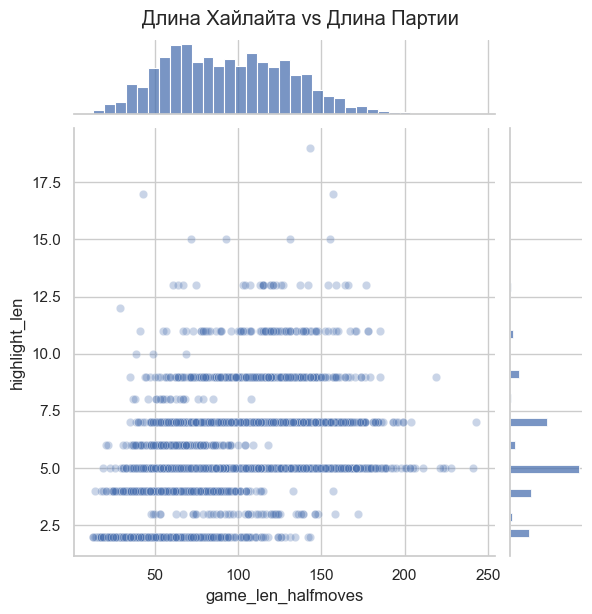

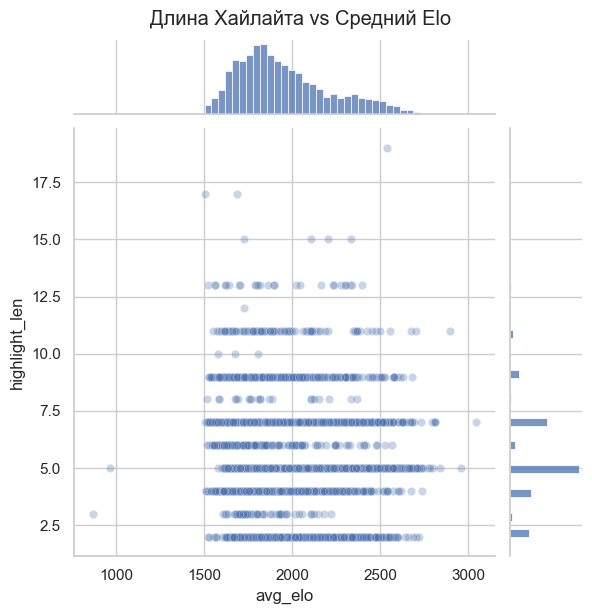

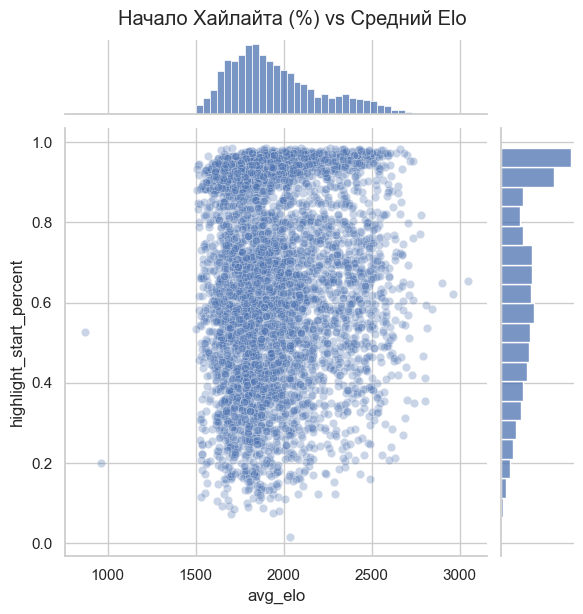

In [29]:
if 'df' in locals():
    # Берем подвыборку для ускорения отрисовки scatter plot
    sample_df = df.sample(n=min(5000, df.shape[0]), random_state=42)

    # Зависимость длины партии от среднего Elo
    sample_df['avg_elo'] = (sample_df['white_elo'] + sample_df['black_elo']) / 2
    sns.jointplot(data=sample_df, x='avg_elo', y='game_len_halfmoves', kind='scatter', alpha=0.3)
    plt.suptitle('Длина Партии vs Средний Elo', y=1.02)
    plt.show()

    # Зависимость длины хайлайта от длины партии
    sns.jointplot(data=sample_df, x='game_len_halfmoves', y='highlight_len', kind='scatter', alpha=0.3)
    plt.suptitle('Длина Хайлайта vs Длина Партии', y=1.02)
    plt.show()

    # Зависимость длины хайлайта от среднего Elo
    sns.jointplot(data=sample_df, x='avg_elo', y='highlight_len', kind='scatter', alpha=0.3)
    plt.suptitle('Длина Хайлайта vs Средний Elo', y=1.02)
    plt.show()

    # Зависимость начала хайлайта (%) от среднего Elo
    sns.jointplot(data=sample_df, x='avg_elo', y='highlight_start_percent', kind='scatter', alpha=0.3)
    plt.suptitle('Начало Хайлайта (%) vs Средний Elo', y=1.02)
    plt.show()

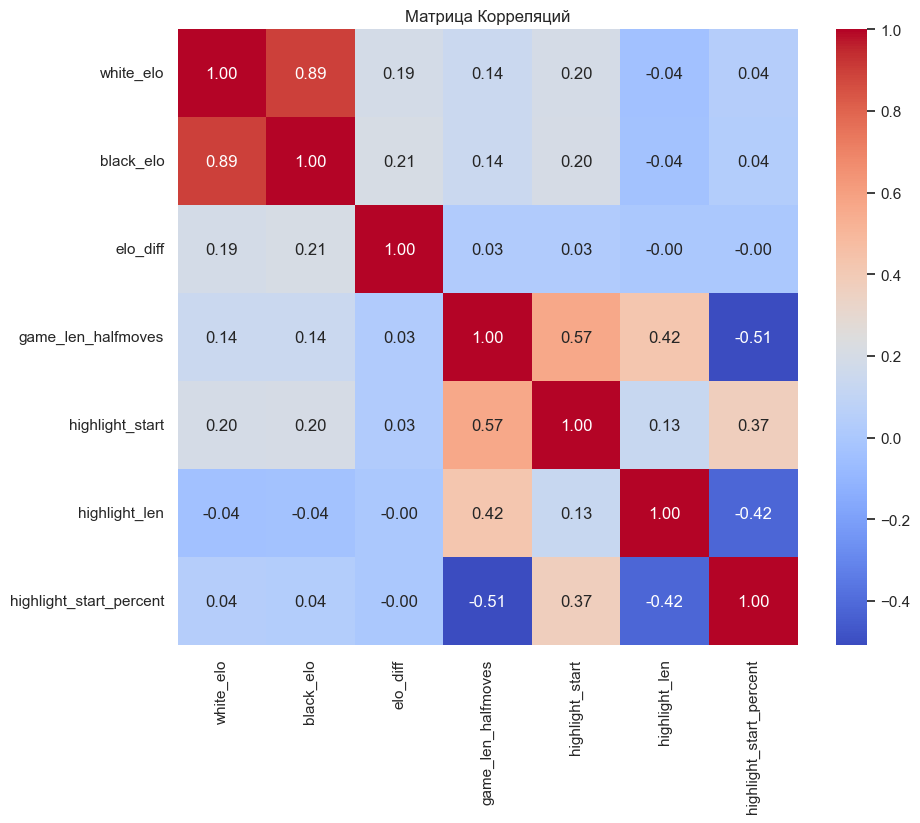

In [27]:
if 'df' in locals():
    corr_cols = ['white_elo', 'black_elo', 'elo_diff', 'game_len_halfmoves', 'highlight_start', 'highlight_len', 'highlight_start_percent']
    correlation_matrix = df[corr_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Матрица Корреляций')
    plt.show()

1.  **Длина Партии vs Средний Elo:**
    *   Диаграмма рассеяния показывает очень **слабую положительную тенденцию**: с ростом среднего рейтинга игроков наблюдается незначительное увеличение средней длины партии. Однако разброс значений очень велик.
    *   Матрица корреляций подтверждает это: корреляция между `game_len_halfmoves` и `white_elo` (0.14) / `black_elo` (0.14) **очень слабая**.
    *   *Вывод:* Уровень игроков слабо влияет на общую продолжительность игры в этом датасете.

2.  **Длина Хайлайта vs Длина Партии:**
    *   Диаграмма рассеяния не показывает явной линейной зависимости. Длина хайлайта сконцентрирована в узком диапазоне (в основном 3-9 полуходов) независимо от общей длины партии.
    *   Матрица корреляций показывает **умеренную положительную корреляцию (0.42)** между `game_len_halfmoves` и `highlight_len`. Это несколько противоречит визуальному впечатлению от диаграммы рассеяния и может быть связано с тем, как считается корреляция для дискретных данных с выбросами, или же некоторая слабая тенденция к чуть более длинным хайлайтам в очень длинных партиях всё же есть. *Однако, учитывая квантили и гистограмму `highlight_len`, можно заключить, что практическая значимость этой корреляции невелика – хайлайты почти всегда короткие.*

3.  **Длина Хайлайта vs Средний Elo:**
    *   Диаграмма рассеяния не показывает никакой видимой зависимости. Длина хайлайта одинаково распределена по всему диапазону Elo.
    *   Матрица корреляций подтверждает **отсутствие связи**: корреляция `highlight_len` с `white_elo` (-0.04) и `black_elo` (-0.04) близка к нулю.
    *   *Вывод:* Сила игроков не влияет на длину выделяемого хайлайта.

4.  **Начало Хайлайта (%) vs Средний Elo:**
    *   Диаграмма рассеяния не показывает четкой тенденции. Хайлайты могут начинаться на любой стадии игры (хотя и с пиком в конце) для всех уровней Elo.
    *   Матрица корреляций подтверждает **отсутствие связи**: корреляция `highlight_start_percent` с `white_elo` (0.04) и `black_elo` (0.04) очень близка к нулю.
    *   *Вывод:* Момент начала хайлайта (в % от длины партии) не зависит от силы игроков.

5.  **Другие Заметные Корреляции:**
    *   **`highlight_start` и `game_len_halfmoves` (0.57):** Сильная положительная корреляция. Это логично: в более длинных партиях абсолютный номер полухода, на котором начинается хайлайт, в среднем выше.
    *   **`highlight_start_percent` и `game_len_halfmoves` (-0.51):** Заметная **отрицательная** корреляция. Это интересно: в **более длинных партиях** хайлайты имеют тенденцию начинаться **относительно раньше** (ближе к середине игры), в то время как в **более коротких партиях** они чаще случаются **в самом конце** (как показал пик на гистограмме `highlight_start_percent`).
    *   **`highlight_start_percent` и `highlight_len` (-0.42):** Заметная **отрицательная** корреляция. Хайлайты, начинающиеся **позже** в партии (ближе к концу), имеют тенденцию быть **короче**. Это согласуется с идеей о том, что поздние хайлайты - это часто короткие решающие комбинации или зевки.

**Общий Вывод по Взаимосвязям:** Ключевые характеристики хайлайтов (`highlight_len`, `highlight_start_percent`) **не зависят от силы игроков (Elo)** в данном датасете. Однако наблюдается интересная связь между длительностью партии и относительным началом хайлайта: в коротких играх хайлайты чаще всего приходятся на самый конец, а в длинных – смещаются ближе к середине. Также поздние хайлайты чаще бывают короткими.

## 6. Итоги EDA и Выбор Репрезентативных Примеров

**Итоги Анализа:**

Проведенный анализ выявил следующие ключевые характеристики датасета:

1.  **Elo:** Основная масса партий сыграна игроками с рейтингом ~1700-1900. Большинство игр проходит между соперниками близкой силы.
2.  **Длина Партии:** Типичная длина ~92 полухода (46 ходов), с большинством партий в диапазоне 64-122 полуходов. Очень короткие и очень длинные партии редки.
3.  **Длина Хайлайта:** Хайлайты преимущественно очень короткие, с медианной длиной 5 полуходов и пиками на 5 и 7 полуходах.
4.  **Начало Хайлайта:** Хайлайты чаще всего происходят во второй половине партии (медиана ~66%), с очень высокой концентрацией в самом конце игры (около 95-100%). В более коротких партиях хайлайты чаще случаются в конце.
5.  **Взаимосвязи:** Характеристики хайлайтов (`highlight_len`, `highlight_start_percent`) практически не зависят от рейтинга Elo игроков.

**Цель Выборки:**

Выбрать примерно **40 репрезентативных партий**, которые отражают разнообразие датасета по ключевым параметрам:

*   Уровень игры (средний Elo).
*   Длительность партии (`game_len_halfmoves`).
*   Относительное время начала хайлайта (`highlight_start_percent`).
*   Длина хайлайта (`highlight_len`).

**Стратегия Выборки: Стратификация**

Для обеспечения разнообразия применим стратифицированную случайную выборку. Мы разделим датасет на группы (страты) на основе квантилей нескольких важных признаков и выберем случайным образом небольшое количество примеров из каждой страты.

**Признаки для Стратификации:**

1.  **Средний Elo (`avg_elo`):** Разделим на 3 группы (например, низкий, средний, высокий Elo).
2.  **Длина Партии (`game_len_halfmoves`):** Разделим на 3 группы (короткая, средняя, длинная).
3.  **Начало Хайлайта (`highlight_start_percent`):** Разделим на 3 группы (раннее, среднее, позднее).

Это даст нам 3 * 3 * 3 = 27 страт. Чтобы получить примерно 40 примеров, мы будем выбирать по 1-2 примера из каждой страты. Выберем по 2, но разрешим брать меньше, если в страте недостаточно данных.